In [6]:
import os
import shutil

# Izvorna i ciljana putanja
source = "kaggle.json"
target_dir = os.path.expanduser("~/.kaggle")
target_file = os.path.join(target_dir, "kaggle.json")

# Napravi .kaggle direktorij ako ne postoji
os.makedirs(target_dir, exist_ok=True)

# Premjesti datoteku
shutil.copy(source, target_file)

# Postavi dozvole (na Windowsu ovo nije obavezno, ali dodano radi konzistentnosti)
os.chmod(target_file, 0o600)

print("✅ kaggle.json kopiran u ~/.kaggle/")


✅ kaggle.json kopiran u ~/.kaggle/


In [ ]:
!kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset -p /content/data --unzip


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Ti


In [2]:
import os

dataset_path = "archive"  # Postavi točnu putanju do dataseta
for root, dirs, files in os.walk(dataset_path):
    print(root)
    for file in files[:5]:  # Prikaz prvih 5 datoteka po direktoriju
        print(f"  {file}")


archive
  class_dict.csv
  metadata.csv
archive\test
  100877_sat.jpg
  103215_sat.jpg
  103742_sat.jpg
  110224_sat.jpg
  112946_sat.jpg
archive\train
  100694_mask.png
  100694_sat.jpg
  102122_mask.png
  102122_sat.jpg
  10233_mask.png
archive\valid
  105036_sat.jpg
  107780_sat.jpg
  108490_sat.jpg
  127801_sat.jpg
  128240_sat.jpg


Priprema labela


In [3]:
# class_dict.csv -> label_map
import pandas as pd
import numpy as np

# Učitaj class_dict i kreiraj mapu: (R, G, B) → label_index
df = pd.read_csv("archive/class_dict.csv")
COLOR2LABEL = {tuple([row.r, row.g, row.b]): idx for idx, row in df.iterrows()}


Dataset klasa(PyTorch)


In [4]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class DeepGlobeDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def rgb_to_label(self, mask):
        mask_array = np.array(mask)
        label_mask = np.zeros(mask_array.shape[:2], dtype=np.uint8)

        for rgb, label in COLOR2LABEL.items():
            matches = np.all(mask_array == rgb, axis=-1)
            label_mask[matches] = label

        return label_mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("RGB")

        label_mask = self.rgb_to_label(mask)

        if self.transform:
            augmented = self.transform(image=np.array(image), mask=label_mask)
            image = augmented["image"]
            label_mask = augmented["mask"]

        return image, label_mask.long()


Transformacije


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])


C:\Users\samue\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Priprema putanja za tren i val


In [6]:
import os
from sklearn.model_selection import train_test_split

image_dir = "data/train"

# Pronađi sve satelitske slike za koje postoji odgovarajuća .png maska
image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.endswith("_sat.jpg") and os.path.exists(os.path.join(image_dir, f.replace("_sat.jpg", "_mask.png")))
])

# Napravi liste punih putanja
image_paths = [os.path.join(image_dir, f) for f in image_files]
mask_paths = [os.path.join(image_dir, f.replace("_sat.jpg", "_mask.png")) for f in image_files]

# Podjela: 70% train, 15% val, 15% test
train_imgs, valtest_imgs, train_masks, valtest_masks = train_test_split(
    image_paths, mask_paths, test_size=0.20, random_state=42)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    valtest_imgs, valtest_masks, test_size=0.5, random_state=42)

print(f"✅ Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")


✅ Train: 642, Val: 80, Test: 81


Dataset i DataLoader


In [7]:
from torch.utils.data import DataLoader

# Transformacije – koristiš iste za validaciju i test, osim augmentacija
train_dataset = DeepGlobeDataset(train_imgs, train_masks, transform=train_transform)
val_dataset = DeepGlobeDataset(val_imgs, val_masks, transform=train_transform)  # bez augmentacije u eval!
test_dataset = DeepGlobeDataset(test_imgs, test_masks, transform=train_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)


**U NET**

In [8]:
!pip install segmentation-models-pytorch


     ---------------------------------------- 0.0/52.0 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.0 kB ? eta -:--:--
     -------------------------------------- 52.0/52.0 kB 663.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/154.8 kB ? eta -:--:--
   --------------------- ------------------ 81.9/154.8 kB 2.3 MB/s eta 0:00:01
   ------------------------------- -------- 122.9/154.8 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 154.8/154.8 kB 1.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/484.2 kB ? eta -:--:--
   ------ --------------------------------- 81.9/484.2 kB 2.3 MB/s eta 0:00:01
   ------------- -------------------------- 163.8/484.2 kB 2.5 MB/s eta 0:00:01
   -------------------- ------------------- 245.8/484.2 kB 2.5 MB/s eta 0:00:01
   ---------------------------- ----------- 348.2/484.2 kB 2.4 MB/s eta 0:00:01
   ------------------------------------- -- 450.6/484.2 kB 2.4 MB/s eta 0:0


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\samue\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",        # Backbone
    encoder_weights="imagenet",     # Pretrained
    in_channels=3,                  # RGB
    classes=7,                      # 7 klasa u DeepGlobeu
)


Loss,optimitzer i metric

In [20]:
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss

dice = DiceLoss(mode='multiclass')
focal = FocalLoss(mode='multiclass', gamma=2.0)

def combined_loss(preds, targets):
    return 0.5 * dice(preds, targets) + 0.5 * focal(preds, targets)


In [22]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [10]:
import numpy as np

def compute_iou(preds, labels, num_classes):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)

    for cls in range(num_classes):
        pred_inds = preds == cls
        label_inds = labels == cls
        intersection = (pred_inds & label_inds).sum().item()
        union = (pred_inds | label_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))  # klasa nije prisutna
        else:
            ious.append(intersection / union)
    return np.nanmean(ious), ious


***TRENING I VALIDACIJE***

In [11]:
def train_loop(model, train_loader, val_loader, optimizer, loss_fn, device, epochs=10, save_path="best_model.pth"):
    model.to(device)
    best_val_loss = float("inf")
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(1, epochs + 1):
        print(f"\n📦 Epoch {epoch}/{epochs}")

        model.train()
        train_loss = 0
        correct_pixels = 0
        total_pixels = 0

        for images, masks in tqdm(train_loader):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pred_classes = torch.argmax(preds, dim=1)
            correct_pixels += (pred_classes == masks).sum().item()
            total_pixels += torch.numel(masks)

        train_loss /= len(train_loader)
        train_acc = correct_pixels / total_pixels

        # VALIDACIJA
        model.eval()
        val_loss = 0
        correct_pixels = 0
        total_pixels = 0
        all_preds = []
        all_masks = []

        with torch.no_grad():
            for images, masks in tqdm(val_loader):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                loss = loss_fn(preds, masks)
                val_loss += loss.item()

                pred_classes = torch.argmax(preds, dim=1)
                correct_pixels += (pred_classes == masks).sum().item()
                total_pixels += torch.numel(masks)

                all_preds.append(pred_classes.cpu())
                all_masks.append(masks.cpu())

        val_loss /= len(val_loader)
        val_acc = correct_pixels / total_pixels

        # Spoji sve predikcije za IoU
        all_preds = torch.cat(all_preds, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        mean_iou, iou_per_class = compute_iou(all_preds, all_masks, num_classes=7)

        print(f"🔹 Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
        print(f"🎯 Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")
        print(f"📊 Val mean IoU: {mean_iou:.4f}")
        print(f"📈 IoU per class: {['{:.2f}'.format(i) for i in iou_per_class]}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"✅ Novi najbolji model spremljen u '{save_path}'")


In [17]:
import torch

if torch.cuda.is_available():
    print("✅ GPU aktivan:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU NIJE aktivan – koristiš CPU.")


✅ GPU aktivan: NVIDIA GeForce RTX 4060 Ti


In [18]:
import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


NVIDIA GeForce RTX 4060 Ti


Glavna train loop fja


In [24]:
from tqdm import tqdm
import numpy as np
import torch

def compute_iou(preds, labels, num_classes, ignore_classes=[6]):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)

    for cls in range(num_classes):
        if cls in ignore_classes:
            continue  # preskoči unknown

        pred_inds = preds == cls
        label_inds = labels == cls
        intersection = (pred_inds & label_inds).sum().item()
        union = (pred_inds | label_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    mean_iou = np.nanmean(ious)
    return mean_iou, ious


def calculate_green_area_percentage(preds, green_classes=[1, 2, 3]):
    """
    Računa postotak piksela koji pripadaju vegetacijskim klasama.
    preds: torch.Tensor oblika (N, H, W) s klasama po pikselima
    green_classes: indeksi klasa vegetacije
    """
    total_pixels = preds.numel()
    green_pixels = sum((preds == cls).sum().item() for cls in green_classes)
    return 100 * green_pixels / total_pixels

def train_loop(model, train_loader, val_loader, optimizer, device, epochs=10, save_path="best_model.pth", num_classes=7):
    model.to(device)
    best_val_loss = float("inf")
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(1, epochs + 1):
        print(f"\n📦 Epoch {epoch}/{epochs}")

        model.train()
        train_loss = 0
        correct_pixels = 0
        total_pixels = 0

        for images, masks in tqdm(train_loader):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            soft_preds = torch.nn.functional.softmax(preds, dim=1)
            loss = combined_loss(soft_preds, masks)

            

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            pred_classes = torch.argmax(preds, dim=1)
            correct_pixels += (pred_classes == masks).sum().item()
            total_pixels += torch.numel(masks)

        train_loss /= len(train_loader)
        train_acc = correct_pixels / total_pixels

        # VALIDACIJA
        model.eval()
        val_loss = 0
        correct_pixels = 0
        total_pixels = 0
        all_preds = []
        all_masks = []

        with torch.no_grad():
            for images, masks in tqdm(val_loader):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                soft_preds = torch.nn.functional.softmax(preds, dim=1)
                loss = combined_loss(soft_preds, masks)

                val_loss += loss.item()

                pred_classes = torch.argmax(preds, dim=1)
                correct_pixels += (pred_classes == masks).sum().item()
                total_pixels += torch.numel(masks)

                all_preds.append(pred_classes.cpu())
                all_masks.append(masks.cpu())

        val_loss /= len(val_loader)
        val_acc = correct_pixels / total_pixels

        # Spoji sve predikcije za IoU
        all_preds = torch.cat(all_preds, dim=0)
        all_masks = torch.cat(all_masks, dim=0)
        mean_iou, iou_per_class = compute_iou(all_preds, all_masks, num_classes=7, ignore_classes=[6])

        # 🔽 Računaj postotak zelenih površina (klase 1, 2, 3)
        green_percent = calculate_green_area_percentage(all_preds, green_classes=[1, 2, 3])

        print(f"🔹 Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
        print(f"🎯 Train acc: {train_acc:.4f} | Val acc: {val_acc:.4f}")
        print(f"📊 Val mean IoU: {mean_iou:.4f}")
        print(f"📈 IoU per class: {[f'{iou:.2f}' if not np.isnan(iou) else 'NaN' for iou in iou_per_class]}")
        print(f"🌿 Zeleni pokrov (val): {green_percent:.2f}%")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"✅ Novi najbolji model spremljen u '{save_path}'")


POKRETANJE TRENINGA

In [25]:
# 📌 Definiraj uređaj
import torch

# 📌 Definiraj uređaj
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ▶️ Pokreni trening petlju
# Pokreni trening petlju
train_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=10,
    save_path="best_model.pth",
    num_classes=7
)





📦 Epoch 1/10


100%|██████████| 10/10 [00:52<00:00,  5.21s/it]


🔹 Train loss: 1.0516 | Val loss: 0.9889
🎯 Train acc: 0.7014 | Val acc: 0.8015
📊 Val mean IoU: 0.4981
📈 IoU per class: ['0.59', '0.81', '0.00', '0.69', '0.34', '0.56']
🌿 Zeleni pokrov (val): 73.31%
✅ Novi najbolji model spremljen u 'best_model.pth'

📦 Epoch 2/10


100%|██████████| 10/10 [00:52<00:00,  5.27s/it]


🔹 Train loss: 1.0278 | Val loss: 0.9778
🎯 Train acc: 0.7402 | Val acc: 0.7697
📊 Val mean IoU: 0.4553
📈 IoU per class: ['0.60', '0.79', '0.00', '0.56', '0.35', '0.44']
🌿 Zeleni pokrov (val): 74.52%
✅ Novi najbolji model spremljen u 'best_model.pth'

📦 Epoch 3/10


...

🔹 Train loss: 0.9744 | Val loss: 0.9445
🎯 Train acc: 0.7965 | Val acc: 0.8242
📊 Val mean IoU: 0.5316
📈 IoU per class: ['0.64', '0.85', '0.00', '0.62', '0.48', '0.60']
🌿 Zeleni pokrov (val): 76.51%

📦 Epoch 9/10


100%|██████████| 10/10 [00:52<00:00,  5.21s/it]


🔹 Train loss: 0.9773 | Val loss: 0.9401
🎯 Train acc: 0.8032 | Val acc: 0.8336
📊 Val mean IoU: 0.5529
📈 IoU per class: ['0.69', '0.83', '0.00', '0.76', '0.43', '0.61']
🌿 Zeleni pokrov (val): 77.11%
✅ Novi najbolji model spremljen u 'best_model.pth'

📦 Epoch 10/10


100%|██████████| 10/10 [00:52<00:00,  5.21s/it]

🔹 Train loss: 0.9725 | Val loss: 0.9386
🎯 Train acc: 0.8075 | Val acc: 0.8334
📊 Val mean IoU: 0.5490
📈 IoU per class: ['0.68', '0.84', '0.00', '0.70', '0.49', '0.58']
🌿 Zeleni pokrov (val): 77.51%
✅ Novi najbolji model spremljen u 'best_model.pth'


**NAJBOLJI MODEL EVALUACIJA I REZULTATI**

In [26]:
# Učitaj najbolji model nakon treniranja
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()


C:\Users\samue\AppData\Local\Temp\ipykernel_21956\4255141811.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [27]:
import pandas as pd

val_df = pd.DataFrame({
    "image_path": val_imgs,
    "mask_path": val_masks
})


In [29]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()


C:\Users\samue\AppData\Local\Temp\ipykernel_21956\1602957884.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

Evaluacija

In [31]:
def compute_iou_per_class(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)
        intersection = (pred_inds & target_inds).sum()
        union = (pred_inds | target_inds).sum()
        if union == 0:
            ious.append(np.nan)  # klasa se ne pojavljuje
        else:
            ious.append(intersection / union)
    return ious


In [32]:
import sklearn.metrics as skm

def compute_confusion_matrix(y_true, y_pred, num_classes):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    return skm.confusion_matrix(y_true_flat, y_pred_flat, labels=list(range(num_classes)))


In [33]:
def compute_accuracy_per_class(conf_matrix):
    accs = []
    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        total = conf_matrix[i, :].sum()
        accs.append(tp / total if total > 0 else np.nan)
    return accs


In [37]:
from tqdm import tqdm
import numpy as np
import torch
import warnings
from sklearn.metrics import confusion_matrix

def calculate_green_area_percentage(preds, green_classes=[1, 2, 3]):
    """
    Računa postotak piksela koji pripadaju vegetacijskim klasama.
    preds: torch.Tensor oblika (N, H, W) s klasama po pikselima
    """
    total_pixels = preds.numel()
    green_pixels = sum((preds == cls).sum().item() for cls in green_classes)
    return 100 * green_pixels / total_pixels

def full_evaluation(model, loader, device, num_classes=7, ignore_class=6, class_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader):
            images = images.to(device)
            preds = model(images)
            preds = torch.argmax(preds, dim=1).cpu()
            masks = masks.cpu()

            all_preds.append(preds)
            all_targets.append(masks)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # Ukloni piksele koji su ignore_class
    valid_pixel_mask = all_targets != ignore_class
    filtered_preds = all_preds[valid_pixel_mask].numpy()
    filtered_targets = all_targets[valid_pixel_mask].numpy()

    # Detektiraj koje klase su stvarno prisutne
    present_classes = sorted(np.unique(filtered_targets))
    valid_classes = [cls for cls in present_classes if cls != ignore_class]

    # Ako nisu dane class_names, generiraj defaultne
    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]

    class_names_valid = [class_names[i] for i in valid_classes]

    # Konfuzijska matrica
    conf_matrix = confusion_matrix(filtered_targets, filtered_preds, labels=valid_classes)

    # Accuracy po klasi
    accs_per_class = compute_accuracy_per_class(conf_matrix)

    # IoU po klasi
    all_ious = []
    for p, t in zip(all_preds, all_targets):
        mask = t != ignore_class
        if mask.sum() == 0:
            continue
        ious = compute_iou_per_class(p[mask].numpy(), t[mask].numpy(), num_classes)
        all_ious.append(ious)

    all_ious = np.array(all_ious)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_ious = np.nanmean(all_ious, axis=0)

    mean_iou_total = np.nanmean([mean_ious[c] for c in valid_classes])
    overall_acc = (filtered_preds == filtered_targets).sum() / filtered_targets.size

    # Računaj zeleni pokrov
    green_percent = calculate_green_area_percentage(all_preds, green_classes=[1, 2, 3])

    # Prikaz po klasi
    print("\n📊 Evaluacija po klasama (ignorirane: Unknown i prazne klase):")
    for i, cls in enumerate(valid_classes):
        print(f"{class_names[cls]}: IoU={mean_ious[cls]:.4f}, Acc={accs_per_class[i]:.4f}")

    print(f"\n🔹 Mean IoU (valjanih klasa): {mean_iou_total:.4f}")
    print(f"🔹 Overall pixel accuracy: {overall_acc:.4f}")
    print(f"🌿 Pokrivenost zelenim površinama (klase 1,2,3): {green_percent:.2f}%")

    return mean_ious, accs_per_class, conf_matrix, class_names_valid, green_percent


NameError: name 'all_targets' is not defined

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(conf_matrix, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


100%|██████████| 11/11 [00:55<00:00,  5.02s/it]



📊 Evaluacija po klasama (ignorirane: Unknown i prazne klase):
Urban: IoU=0.3791, Acc=0.8820
Agriculture: IoU=0.6667, Acc=0.9623
Rangeland: IoU=0.0015, Acc=0.0029
Forest: IoU=0.1336, Acc=0.8158
Water: IoU=0.1184, Acc=0.6928
Barren: IoU=0.1335, Acc=0.4771

🔹 Mean IoU (valjanih klasa): 0.2388
🔹 Overall pixel accuracy: 0.7990
🌿 Pokrivenost zelenim površinama (klase 1,2,3): 78.45%


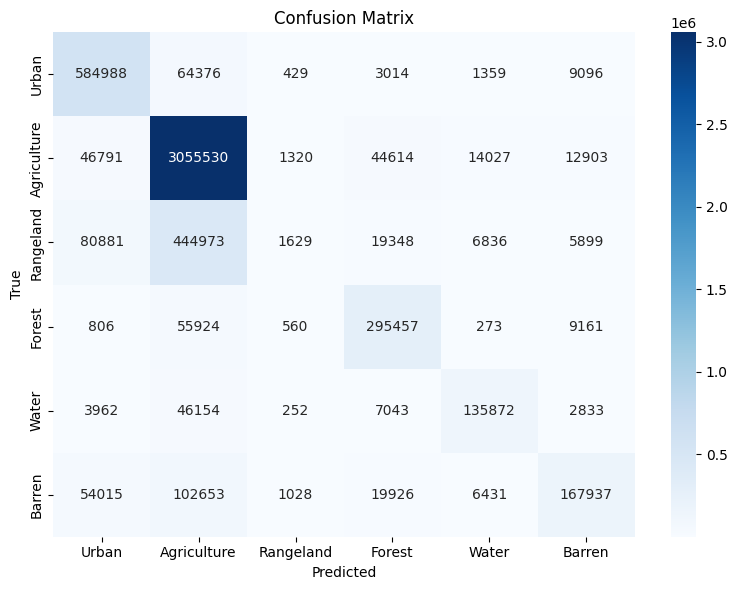

In [39]:
class_names = ["Urban", "Agriculture", "Rangeland", "Forest", "Water", "Barren", "Unknown"]

mean_ious, accs, conf_matrix, class_names_valid, green_percent = full_evaluation(
    model=model,
    loader=test_loader,
    device=device,
    num_classes=7,
    ignore_class=6,
    class_names=class_names
)


# Prikaz konfuzijske matrice
plot_conf_matrix(conf_matrix, class_names_valid)


NameError: name 'train_losses' is not defined

<Figure size 1000x500 with 0 Axes>